## Trabajo Computacional 2 - Aceleradores y detectores de partículas 

***Grupo:*** Catalina Fuentes (202220750), Daniela León (202211020), David Cantini (202212169)

***Fundamento del problema:*** 
Un protón de 100 MeV penetra en Silicio y pierde energía continuamente por ionización (fórmula de Bethe-Bloch). El alcance R es la profundidad total hasta que el protón se detiene.

### Parte A — dE/dx en función de E

La gráfica de la página 17 de Marion & Young muestra el poder de frenado (stopping power) dE/dx vs la energía E de protones en Silicio en escala logarítmica. El eje Y está en keV/mm y el eje X en MeV. Esta cantidad describe cuánta energía pierde el protón por milímetro recorrido.

 La curva sigue aproximadamente una ley de potencia, lo que en escala logarítmica se traduce en una línea casi recta. Por eso, ajustar un polinomio de grado 2 en log(E) vs log(dE/dx) es una buena aproximación: equivale a ajustar una parábola sobre la curva logarítmica, capturando tanto la tendencia general como la curvatura del pico de Bragg. Es importante recordar la fórmula de Bethe-Bloch relativista, que es la expresión teórica exacta para la pérdida de energía de partículas cargadas pesadas en materia:

$$
-\frac{dE}{dx} = K z^2 \frac{Z}{A} \frac{1}{\beta^2}
\left[
\frac{1}{2} \ln\left(\frac{2 m_e c^2 \beta^2 \gamma^2 W_{\text{max}}}{I^2}\right)
- \beta^2
\right] \cdot \rho
$$

donde I = 173 eV es la energía de excitación media del Silicio, Z=14, A=28, ρ=2.336 g/cm³.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# PARTE a) — TABLA E vs dE/dx y AJUSTE POLINOMIAL G

# ¿QUÉ SE HACE?:
#   Se construye una tabla de varios puntos (E, dE/dx) leyendo la curva
#   de PROTONS de la gráfica pág.17 de Marion & Young.
#   Luego se ajusta un polinomio de grado 3 en escala logarítmica para
#   obtener dE/dx(E) para cualquier valor de E.

# ¿POR QUÉ SE HACE?:
#   La integración numérica del paso b) requiere evaluar dE/dx a
#   energías arbitrarias entre 0 y 100 MeV. El ajuste polinomial
#   en escala logarítmica captura bien la forma de la curva (casi lineal en
#   esa escala) con muy pocos coeficientes.

# SIGNIFICADO FÍSICO:
#   dE/dx es el "poder de frenado" (stopping power): la energía
#   depositada por el protón por unidad de longitud recorrida.
#   A energías altas el protón deposita menos energía, mientras
#   que a energías bajas la pérdida aumenta (pico de Bragg).



# PASO 1: TABLA DE PUNTOS E VS dE/dx (LEÍDOS DE LA GRÁFICA)

E_tabla = np.array([0.10, 0.20, 0.30, 0.50, 0.70,
                    1.00, 1.50, 2.00, 3.00, 5.00, 7.00,
                    10.0, 15.0, 20.0, 30.0, 50.0, 70.0, 100., 150.])

dEdx_keV_mm = np.array([105.0, 88.0, 78.0, 66.0, 56.0,
                        45.0, 36.0, 27.0, 21.5, 14.5, 10.5,
                        8.5, 6.6, 5.0, 4.0, 2.8, 2.2, 1.6, 1.0])

# Los valores tienen una incertidumbre estimada del orden del 5–10%
# debido a la lectura manual en escala logarítmica.

# Imprimir la tabla completa

print("TABLA a) — Puntos leídos de la gráfica pág.17")
print("           Protones en Silicio (Marion & Young)")
print("-" * 55)
print(f"{'E (MeV)':>10} | {'dE/dx (keV/mm)':>16}")
print("-" * 35)
for e, dk in zip(E_tabla, dEdx_keV_mm):
    print(f"{e:>10.2f} | {dk:>16.2f}")



TABLA a) — Puntos leídos de la gráfica pág.17
           Protones en Silicio (Marion & Young)
-------------------------------------------------------
   E (MeV) |   dE/dx (keV/mm)
-----------------------------------
      0.10 |           105.00
      0.20 |            88.00
      0.30 |            78.00
      0.50 |            66.00
      0.70 |            56.00
      1.00 |            45.00
      1.50 |            36.00
      2.00 |            27.00
      3.00 |            21.50
      5.00 |            14.50
      7.00 |            10.50
     10.00 |             8.50
     15.00 |             6.60
     20.00 |             5.00
     30.00 |             4.00
     50.00 |             2.80
     70.00 |             2.20
    100.00 |             1.60
    150.00 |             1.00


In [2]:
# PASO 2: Ajuste polinomial grado 3 en escala logarítmica

log_E    = np.log10(E_tabla)
log_dEdx = np.log10(dEdx_keV_mm)

coeff2 = np.polyfit(log_E, log_dEdx, 3)

print(f"\nCoeficientes del polinomio grado 3 (log-log):")
print(f"  a3 = {coeff2[0]:.5f}")
print(f"  a2 = {coeff2[1]:.5f}")
print(f"  a1 = {coeff2[2]:.5f}")
print(f"  a0 = {coeff2[3]:.5f}")
print(f"\nFórmula: log10(dE/dx [keV/mm]) = "
      f"{coeff2[0]:.5f}·[log10(E)]³ "
      f"+ {coeff2[1]:.5f}·[log10(E)]² "
      f"+ {coeff2[2]:.5f}·log10(E) "
      f"+ {coeff2[3]:.5f}")


def dEdx_grafica(E_MeV):
    E_s   = np.maximum(np.asarray(E_MeV, float), 0.05)
    log_E_input = np.log10(E_s)
    log_dEdx_output = np.polyval(coeff2, log_E_input)
    return 10**log_dEdx_output


Coeficientes del polinomio grado 3 (log-log):
  a3 = 0.03674
  a2 = -0.14902
  a1 = -0.57626
  a0 = 1.63920

Fórmula: log10(dE/dx [keV/mm]) = 0.03674·[log10(E)]³ + -0.14902·[log10(E)]² + -0.57626·log10(E) + 1.63920


In [3]:
# PASO 3: Verificar la calidad del ajuste

print(f"\n{'E (MeV)':>8} | {'Gráfica (keV/mm)':>18} | "
      f"{'Poly-3 (keV/mm)':>18} | {'Error%':>8}")
print("-" * 60)
for e, d in zip(E_tabla, dEdx_keV_mm):
    p   = dEdx_grafica(e)
    err = 100 * (p - d) / d
    print(f"{e:>8.2f} | {d:>18.2f} | {p:>18.2f} | {err:>8.1f}%")



 E (MeV) |   Gráfica (keV/mm) |    Poly-3 (keV/mm) |   Error%
------------------------------------------------------------
    0.10 |             105.00 |             107.08 |      2.0%
    0.20 |              88.00 |              90.50 |      2.8%
    0.30 |              78.00 |              78.44 |      0.6%
    0.50 |              66.00 |              62.83 |     -4.8%
    0.70 |              56.00 |              53.06 |     -5.3%
    1.00 |              45.00 |              43.57 |     -3.2%
    1.50 |              36.00 |              34.14 |     -5.2%
    2.00 |              27.00 |              28.39 |      5.2%
    3.00 |              21.50 |              21.59 |      0.4%
    5.00 |              14.50 |              15.00 |      3.5%
    7.00 |              10.50 |              11.69 |     11.4%
   10.00 |               8.50 |               8.93 |      5.0%
   15.00 |               6.60 |               6.53 |     -1.0%
   20.00 |               5.00 |               5.23 |     

***NOTA:***


Aunque la guía sugería realizar un ajuste de polinomio de grado 2, optamos por un polinomio de grado 3 por las siguientes razones:

*La media del error de la interpolación de grado 2 es 7.28%; mientras que, la del polinomio de grado 3 es 5.05%.

*De los 19 datos recopilados, la interpolación con el polinomio de grado 2 solamente toca 8 puntos. Por otro lado, con el polinomio de grado 3 se cruzan 14 puntos.

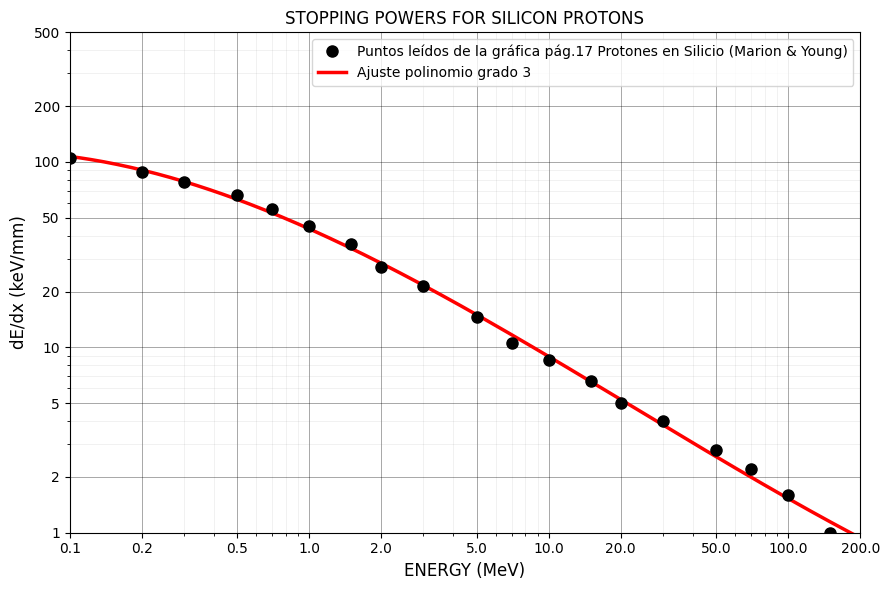

In [4]:
# PASO 4: Gráfica

E_plot     = np.logspace(np.log10(0.1), np.log10(200), 300)
dEdx_ajuste = dEdx_grafica(E_plot)

fig, ax = plt.subplots(figsize=(9, 6))

ax.set_xscale('log')
ax.set_yscale('log')

x_ticks = [0.1, 0.2, 0.5, 1, 2, 5, 10, 20, 50, 100, 200]
y_ticks = [1, 2, 5, 10, 20, 50, 100, 200, 500]

ax.set_xticks(x_ticks)
ax.set_yticks(y_ticks)

ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())
ax.get_yaxis().set_major_formatter(plt.ScalarFormatter())

ax.grid(which='major', color='black', alpha=0.4, linewidth=0.6)
ax.grid(which='minor', color='gray', alpha=0.2, linewidth=0.4)

ax.minorticks_on()

ax.plot(E_tabla, dEdx_keV_mm, 'ko', ms=8, zorder=5,
        label='Puntos leídos de la gráfica pág.17 Protones en Silicio (Marion & Young)')
ax.plot(E_plot, dEdx_ajuste, 'r-', lw=2.5,
        label='Ajuste polinomio grado 3')

ax.set_xlim(0.1, 200)
ax.set_ylim(1, 500)

ax.set_xlabel('ENERGY (MeV)', fontsize=12)
ax.set_ylabel('dE/dx (keV/mm)', fontsize=12)

ax.set_title('STOPPING POWERS FOR SILICON PROTONS', fontsize=12)

ax.legend()
plt.tight_layout()
plt.show()

### Parte B — Cálculo numérico del alcance R

El alcance (range) R de una partícula cargada en un material es la distancia total que recorre hasta detenerse. 

Formalmente es la integral: 

$$
R = \int_{0}^{E_i} \frac{dE}{dE/dx}
$$

Se nos pide calcular numéricamente esta variable por el método de Euler hacia adelante: se avanza en pasos discretos de espesor ΔX, y en cada paso se descuenta la energía perdida según el stopping power a la energía actual. Este es el esquema:

$$ X_{n+1} = X_n + \Delta X $$

$$ E_{n+1} = E_n - \left(\frac{dE}{dx}\right)_{E_n} \cdot \Delta X $$

Se repite hasta que $ E_{n+1} \leq 0 $. El valor de X en ese momento es el alcance R.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# PARTE b) — CÁLCULO NUMÉRICO DEL ALCANCE R

# ¿QUÉ SE HACE?:
#   Se implementa un método de integración por pasos (Euler):
#   el cristal de Si se divide en láminas de espesor deltaX.
#   El protón pierde energía en cada paso según dE/dx(E).
#   El proceso se repite hasta E = 0, obteniendo el alcance R.
#
# ¿POR QUÉ SE HACE?:
#   La integral R = ∫ dE/(dE/dx) no tiene forma analítica
#   porque dE/dx viene de datos experimentales.
#   Se usa un esquema numérico iterativo equivalente a Euler.
#
# SIGNIFICADO FÍSICO:
#   Cada paso representa una lámina de material.
#   El protón entra con energía E, ioniza los
#   átomos del Si depositando deltaE = (dE/dx)*deltaX, y sale
#   con E - deltaE para entrar a la siguiente lámina. Cuando
#   E ≤ 0 el protón está detenido: ha recorrido el alcance R.
#   Este cálculo predice dónde se deposita la dosis máxima
#   en el material

#PASO 0: Para un mejor ajuste a bajas energías, calcular el dE/dx mediante una interpolación:
interp_log = interp1d(log_E, log_dEdx, kind='linear', fill_value="extrapolate")
def dEdx_grafica(E_MeV):
    E_s = np.maximum(np.asarray(E_MeV, float), 0.05)
    logE = np.log10(E_s)
    log_dEdx_interp = interp_log(logE)
    dEdx = 10**log_dEdx_interp
    return dEdx * 1000



In [6]:
# PASO 1: Definir parámetros del cálculo
E0       = 100.0   # MeV  — energía inicial del protón (dato del problema)
deltaX   = 0.01    # mm   — espesor de cada lámina del cristal

In [7]:
# PASO 2: Algoritmo de integración de Euler

#   Se implementan las fórmulas del enunciado:
#     X_nueva      = X_anterior + deltaX
#     E_nueva      = E_anterior - (dE/dx)(E_anterior) * deltaX
#   y se guardan los pares {X_actual, deltaE} en arreglos.

X       = 0.0    # profundidad actual (mm) — inicia en la superficie
E       = E0     # energía actual (MeV)    — inicia con E0

# Arreglos para guardar el par {X_actual, deltaE}
X_array  = [X]   # profundidades en mm
dE_array = []    # deltaE depositado en cada paso (keV)
E_array  = [E]   # energía en cada paso (MeV), útil para graficar

while E > 0:

    # Evaluar dE/dx a la ENERGÍA ANTERIOR (esquema de Euler)
    # Físicamente: la capacidad de frenado de la lámina depende
    # de la velocidad con que el protón entra a ella.
    dEdx = dEdx_grafica(E)           # keV/mm

    # Calcular pérdida de energía en esta lámina
    # deltaE [keV] = dE/dx [keV/mm] * deltaX [mm]
    deltaE_keV = dEdx * deltaX       # keV
    deltaE_MeV = deltaE_keV / 1000.0 # MeV — conversión para restar a E

    # Guardar el par {profundidad X actual, deltaE} que pide el enunciado
    dE_array.append(deltaE_keV)      # en keV

    # Verificar si el protón se detiene dentro de esta lámina
    if E - deltaE_MeV <= 0:
        # El protón no tiene energía para cruzar la lámina completa.
        # Interpolamos la fracción del paso recorrida antes de E = 0:
        #   frac = E_actual / deltaE_total  (entre 0 y 1)
        frac   = E / deltaE_MeV
        X      = X + frac * deltaX   # alcance exacto interpolado (mm)
        X_array.append(X)
        E_array.append(0.0)
        break                        # el protón se detuvo: fin del bucle

    # Avanzar al siguiente paso (fórmulas literales del enunciado):
    #   X_nueva = X_anterior + deltaX
    #   E_nueva = E_anterior - (dE/dx)(E_anterior) * deltaX
    X = X + deltaX
    E = E - deltaE_MeV
    X_array.append(X)
    E_array.append(E)

# Convertir a arrays de numpy para operar con ellos en c) y d)
X_array  = np.array(X_array)
dE_array = np.array(dE_array)
E_array  = np.array(E_array)
R        = X_array[-1]   # alcance R = última profundidad alcanzada (mm)

In [8]:
# PASO 3: Imprimir resultados
print("RESULTADO PARTE b) — Alcance R de protones en Si")
print("-" * 52)
print(f"  Energía inicial E₀        : {E0:.1f} MeV")
print(f"  Tamaño del paso deltaX    : {deltaX} mm")
print(f"  Número de pasos realizados: {len(dE_array)}")
print(f"  dE/dx inicial (100 MeV)   : {dEdx_grafica(E0):.3f} keV/mm")
print(f"  deltaE primer paso        : {dE_array[0]:.4f} keV")
print(f"  deltaE último paso        : {dE_array[-1]:.4f} keV")
print(f"\n ALCANCE  R = {R:.3f} mm")




RESULTADO PARTE b) — Alcance R de protones en Si
----------------------------------------------------
  Energía inicial E₀        : 100.0 MeV
  Tamaño del paso deltaX    : 0.01 mm
  Número de pasos realizados: 3496
  dE/dx inicial (100 MeV)   : 1600.000 keV/mm
  deltaE primer paso        : 16.0000 keV
  deltaE último paso        : 644.2290 keV

 ALCANCE  R = 34.958 mm


In [12]:
# PASO 4: Estudio de convergencia — verificar que deltaX es suficientemente pequeño
#   Se repite el cálculo con distintos valores de deltaX y se
#   compara el resultado de R. Cuando R deja de cambiar
#   apreciablemente al reducir el paso, el cálculo convergió.

#   Si al reducir deltaX a la mitad R cambia menos de 0.1 mm
#   (< 0.3% del alcance total), el paso elegido es adecuado.

print("CONVERGENCIA — R en función del paso deltaX")
print("-" * 48)
print(f"{'deltaX (mm)':>14} | {'R (mm)':>10} | {'|ΔR| vs anterior':>18}")
print("-" * 48)

R_anterior = None
for dX_test in [0.5, 0.25, 0.125, 0.0625, 0.03125,0.015625]:   # se quitó 0.001 (~100 000 iteraciones)
    X_t, E_t = 0.0, E0
    while E_t > 0:
        dEdx_t    = dEdx_grafica(E_t)
        dE_t      = dEdx_t * dX_test / 1000.0
        if E_t - dE_t <= 0:
            X_t += (E_t / dE_t) * dX_test
            break
        X_t += dX_test
        E_t -= dE_t
    if R_anterior is not None:
        diff = abs(X_t - R_anterior)
        print(f"{dX_test:>14.4f} | {X_t:>10.4f} | {diff:>18.4f} mm")
    else:
        print(f"{dX_test:>14.4f} | {X_t:>10.4f} | {'—':>18}")
    R_anterior = X_t

CONVERGENCIA — R en función del paso deltaX
------------------------------------------------
   deltaX (mm) |     R (mm) |   |ΔR| vs anterior
------------------------------------------------
        0.5000 |    35.5755 |                  —
        0.2500 |    35.2833 |             0.2922 mm
        0.1250 |    35.1322 |             0.1511 mm
        0.0625 |    35.0422 |             0.0900 mm
        0.0312 |    34.9968 |             0.0454 mm
        0.0156 |    34.9688 |             0.0280 mm


***Nota***

Por esta prueba de convergencia podemos verificar que nuestro deltaX empleado es adecuado pues |ΔR|< 0.028 mm. 

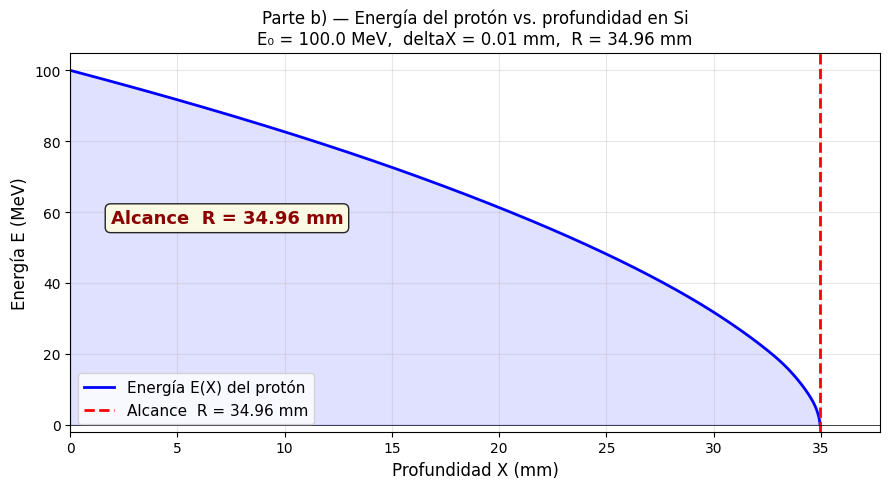

In [11]:
# PASO 5: Gráfica — Energía del protón vs. profundidad

#   La curva cae lentamente al inicio (protón rápido → dE/dx pequeño)
#   y cada vez más rápido al acercarse al final (protón lento → dE/dx grande). Llega a cero exactamente en X = R.

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(X_array, E_array, 'b-', lw=2, label='Energía E(X) del protón')
ax.axvline(R, color='red', ls='--', lw=2, label=f'Alcance  R = {R:.2f} mm')
ax.axhline(0, color='black', lw=0.5)
ax.fill_between(X_array, 0, E_array, alpha=0.12, color='blue')

ax.set_xlabel('Profundidad X (mm)', fontsize=12)
ax.set_ylabel('Energía E (MeV)',    fontsize=12)
ax.set_title(f'Parte b) — Energía del protón vs. profundidad en Si\n'
             f'E₀ = {E0} MeV,  deltaX = {deltaX} mm,  R = {R:.2f} mm',
             fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, R * 1.08)
ax.set_ylim(-2, 105)
ax.text(0.05, 0.55, f'Alcance  R = {R:.2f} mm',
        transform=ax.transAxes, fontsize=13, fontweight='bold', color='darkred',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.85))

plt.tight_layout()
plt.show()

### Parte C — Comentario acerca de la exactitud alcanzada con el valor obtenido del alcance R

La gráfica de la página 5 de Marion & Young muestra las diferencias de los alcances del silicio (Range differences for Silicon) para diferentes partículas: la energía E (MeV) vs la diferencia de rango (1 MeV)(mm) en escala logarítmica. Esta cantidad describe cuál es la distancia máxima que recorre el protón dentro del silicio; en nuestro caso, el alcance máximo es R = 50 mm.

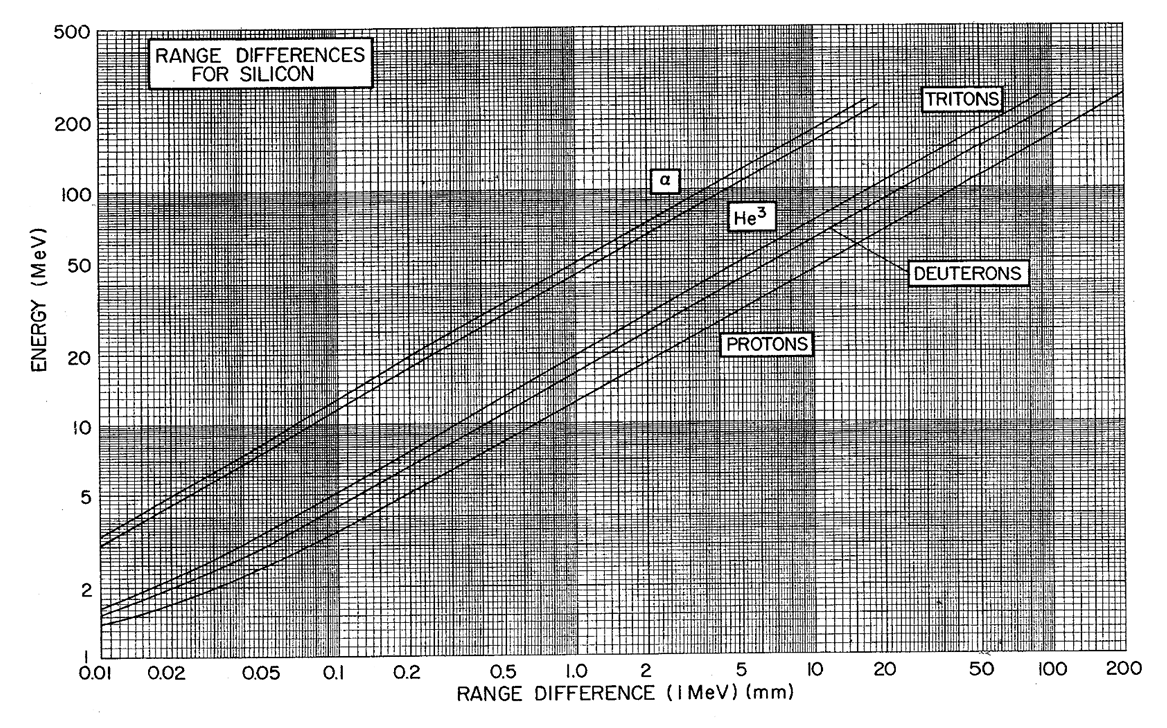

Asimismo, la siguiente tabla informa la incertidumbre del alcance de diferentes partículas en distintos materiales. Específicamente, nos enfocamos en el dato del protón atravesando el silicio: 0.0170 mm.

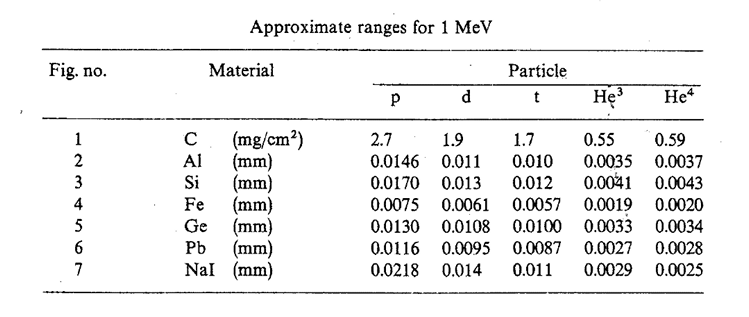

Para comenzar, el valor teórico del alcance de los protones atravesando el Silicio con una energía de 100 MeV es de 50.0170 mm:

$$
R = ΔR (100 MeV) + R(1 MeV).
$$

Mediante el cálculo numérico se obtuvo un rango de 34.96 mm. Aunque el valor estimado coincide con el teórico en el mismo orden de magnitid, persiste una diferencia significativa entre ambos resultados.

En el cálculo del stopping power se identificó que el ajuste polinómico subestimaba dE/dx en la región de bajas energías. Esto ocurre porque la suavidad del polinomio no reproduce adecuadamente el incremento pronunciado de esta magnitud, característico del pico de Bragg. Por esta razón, se utilizó una interpolación con el fin de representar de mejor manera dicho comportamiento. Aun así, el resultado numérico continuó siendo menor que el valor teórico esperado, lo que sugiere que tanto la discretización como la limitada resolución de los datos en la región de bajas energías introducen un sesgo importante en el cálculo del alcance

Por otro lado, con respecto a la exactitud se evidenció que el método de Euler muestra una convergencia adecuada al reducir el tamaño del paso ΔX (error númerico mínimo). Sin embargo, al emplear la fórmula del error relativo (donde X_e es el valor experimental y X_t es el valor teórico):


$$
E_R = |\frac{X_e - X_t}{X_t}|,
$$

se demuestra que el error es del 30.1%. Este podría ser una consecuencia directa del error exponencial en la aproximación del stopping power dE/dx, particularmente en el rango de las bajas energías.



### Parte D — Relación entre el alcance de la partícula dentro del material con su pérdida de energía

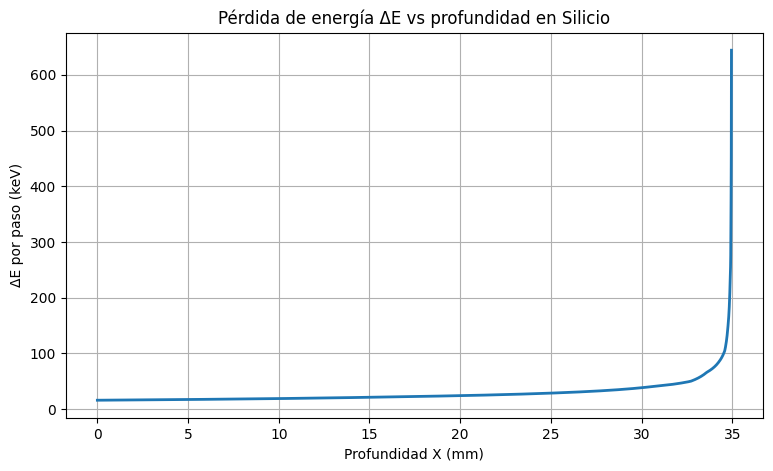

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# PARTE d) — GRÁFICA ΔE POR PASO VS PROFUNDIDAD 

# ¿QUÉ SE HACE?:
#   Se realiza una gráfica con los valores obtenidos del numeral b:
#   el cambio de energía por paso (deltaE) vs. la profundidad X.

# ¿POR QUÉ SE HACE?:
#   Esta gráfica muestra cómo varía la pérdida de energía del protón a medida que atraviesa el material. 
#   Es una representación visual del poder de frenado a lo largo de la trayectoria, evidenciando el 
#   aumento de dE/dx a bajas energías (pico de Bragg) y la disminución a altas energías.

# SIGNIFICADO FÍSICO:
#   A medida que el protón atraviesa el Silicio debe perder energía para ionizar los átomos del material.
#   Al inicio, con energía alta, el protón pierde poca energía por paso (dE/dx pequeño). A medida que se 
#   ralentiza, el poder de frenado aumenta, y el protón deposita más energía por paso, antes de detenerse
#   por completo logra su alcance el máximo. Este alcance se conoce como el pico de Bragg.

# PROCEDIMIENTO:
#  Se toman los arrays registrados en el inciso b) de Profundidad X y cambio de energía por paso dE.
#  Como el array dE tiene un elemento menos, se sustrae su último valor.

plt.figure(figsize=(9,5))

plt.plot(X_array[:-1], dE_array, lw=2)
ax.set_xlim(0, R + 10)
plt.xlabel("Profundidad X (mm)")
plt.ylabel("ΔE por paso (keV)")
plt.title("Pérdida de energía ΔE vs profundidad en Silicio")

plt.grid(True)
plt.show()

A partir de la gráfica se puede concluir que el alcance de la partícula es de 35 mm aproximadamente pues, como el protón entregó toda su energía cinética se encuentra detenido dentro del material. Asi mismo, se puede observar que la pérdida de energía incrementa levemente durante la mayor parte de la trayectoría del protón X(0 mm - 30 mm); sin embargo, aproximadamente en X(32 mm) se evidencia un aumento súbito.